   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
Confusion Matrix:
 [[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]

Accuracy: 1.0000
Error Rate: 0.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000

Class: Iris-setosa
TP: 16, FP: 0, TN: 29, FN: 0

Class: Iris-versicolor
TP: 18, FP: 0, TN: 27, FN: 0

Class: Iris-virginica
TP: 11, FP: 0, TN: 34, FN: 0


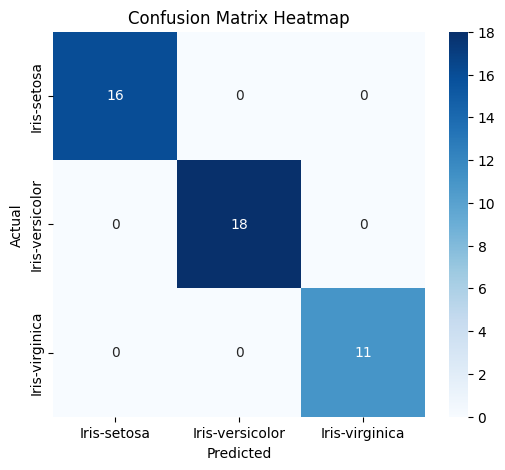

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("IRIS.csv")

print(df.head(2))  # sanity check

# -------------------------------
# Encode target column
# -------------------------------
le = LabelEncoder()
df['Species_encoded'] = le.fit_transform(df['species'])

# -------------------------------
# Feature selection
# -------------------------------
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['Species_encoded']

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# -------------------------------
# Train Naïve Bayes Model
# -------------------------------
nb = GaussianNB()
nb.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = nb.predict(X_test)

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

# -------------------------------
# Metrics
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

# -------------------------------
# TP, FP, TN, FN
# -------------------------------
TP = cm.diagonal()
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

# -------------------------------
# Output
# -------------------------------
print("Confusion Matrix:\n", cm)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")

for i, cls in enumerate(le.classes_):
    print(f"\nClass: {cls}")
    print(f"TP: {TP[i]}, FP: {FP[i]}, TN: {TN[i]}, FN: {FN[i]}")

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()